In [4]:
import numpy as np  # Linear algebra
import pandas as pd  # Data processing
import matplotlib.pyplot as plt  # Visualization
import seaborn as sns  # Statistical Data Visualization
import math  # Mathematical operations
import folium  # Interactive map visualization
import plotly.offline as offline  # Interactive visualization
import plotly.graph_objs as go  # Graph objects for Plotly
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from datetime import datetime

In [5]:
# Set theme for seaborn
sns.set_theme(style='darkgrid')

In [6]:
# ===============================
# 1. Load Dataset
# ===============================
df = pd.read_csv('/kaggle/input/uberdata/final_internship_data.csv')
df.head()

,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,KHVrEVlD,Kimberly Adams,Amy Butler,Very Good,windy,Congested Traffic,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21,-1.288826,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,lPxIuEri,Justin Tapia,Hannah Zimmerman,Excellent,cloudy,Flow Traffic,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16,-1.291824,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,gsVN8JLS,Elizabeth Lopez,Amanda Jackson,Bad,stormy,Congested Traffic,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00,-1.291242,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,9I7kWFgd,Steven Wilson,Amy Horn,Very Good,stormy,Flow Traffic,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42,-1.291319,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,8QN5ZaGN,Alexander Andrews,Cassandra Larson,Bad,stormy,Congested Traffic,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00,-1.290987,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


In [7]:
# ===============================
# 2. Data Cleaning & Preprocessing
# ===============================


In [8]:
# Drop unneeded ID column
df.drop(columns="User ID", axis=1, inplace=True)

In [9]:
# Handling passenger count: Replace zero passengers with 1
df['passenger_count'] = df['passenger_count'].apply(lambda x: 1 if x == 0 else x)

In [10]:
# Drop rows with missing values in distance metrics
df.dropna(inplace=True)

In [11]:
# Remove extreme fare values
df.drop(df[(df['fare_amount'] > 200) | (df['fare_amount'] < 2.5)].index, inplace=True)

In [12]:
# Outlier detection and removal based on ride distance
df = df[(df['distance'] > 0) & (df['distance'] <= 200)]

In [13]:
# Cap unrealistic airport distances using IQR method
for col in ['jfk_dist', 'ewr_dist', 'lga_dist']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr  # Allow some variation
    df = df[df[col] <= upper_bound]

In [14]:
# ===============================
# 3. Feature Engineering
# ===============================
# Convert pickup_datetime to datetime format
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

In [15]:
# Extract time-based features
df['minute'] = df['pickup_datetime'].dt.minute
df['day_of_year'] = df['pickup_datetime'].dt.dayofyear
df['quarter'] = df['pickup_datetime'].dt.quarter
df['time_of_day'] = df['pickup_datetime'].dt.hour.apply(lambda x: 'Night' if x < 6 else ('Morning' if x < 12 else ('Afternoon' if x < 18 else 'Evening')))
df['rush_hour'] = df['pickup_datetime'].dt.hour.apply(lambda x: 1 if (7 <= x <= 9 or 16 <= x <= 19) else 0)
df['weekend'] = df['pickup_datetime'].dt.weekday.apply(lambda x: 1 if x in [5, 6] else 0)

In [16]:
# Drop original datetime columns
df.drop(['pickup_datetime'], axis=1, inplace=True)

In [17]:
# Bin distance into categories
bins = [0, 2, 5, 10, 20, 50, 200]
labels = ['Very Short', 'Short', 'Medium', 'Long', 'Very Long', 'Extreme']
df['distance_bin'] = pd.cut(df['distance'], bins=bins, labels=labels)

In [18]:
# Compute price per mile
df['price_per_mile'] = df['fare_amount'] / df['distance']

In [19]:
# ===============================
# 4. Encoding Categorical Variables
# ===============================
# Ordinal encoding for ordered categories
ordinal_features = {'Car Condition': ['Bad', 'Average', 'Good', 'Very Good', 'Excellent'],
                    'Traffic Condition': ['Flow Traffic', 'Dense Traffic', 'Congested Traffic'],
                    'distance_bin': ['Very Short', 'Short', 'Medium', 'Long', 'Very Long', 'Extreme']}
ordinal_encoder = OrdinalEncoder(categories=[ordinal_features[col] for col in ordinal_features], handle_unknown='use_encoded_value', unknown_value=-1)
df[list(ordinal_features.keys())] = ordinal_encoder.fit_transform(df[list(ordinal_features.keys())])

In [20]:
# One-hot encoding for unordered categorical variables
#df = pd.get_dummies(df, columns=['Weather', 'time_of_day'], drop_first=True)

In [21]:
# Drop redundant columns
#df.drop(['minute', 'day_of_year'], axis=1, inplace=True)

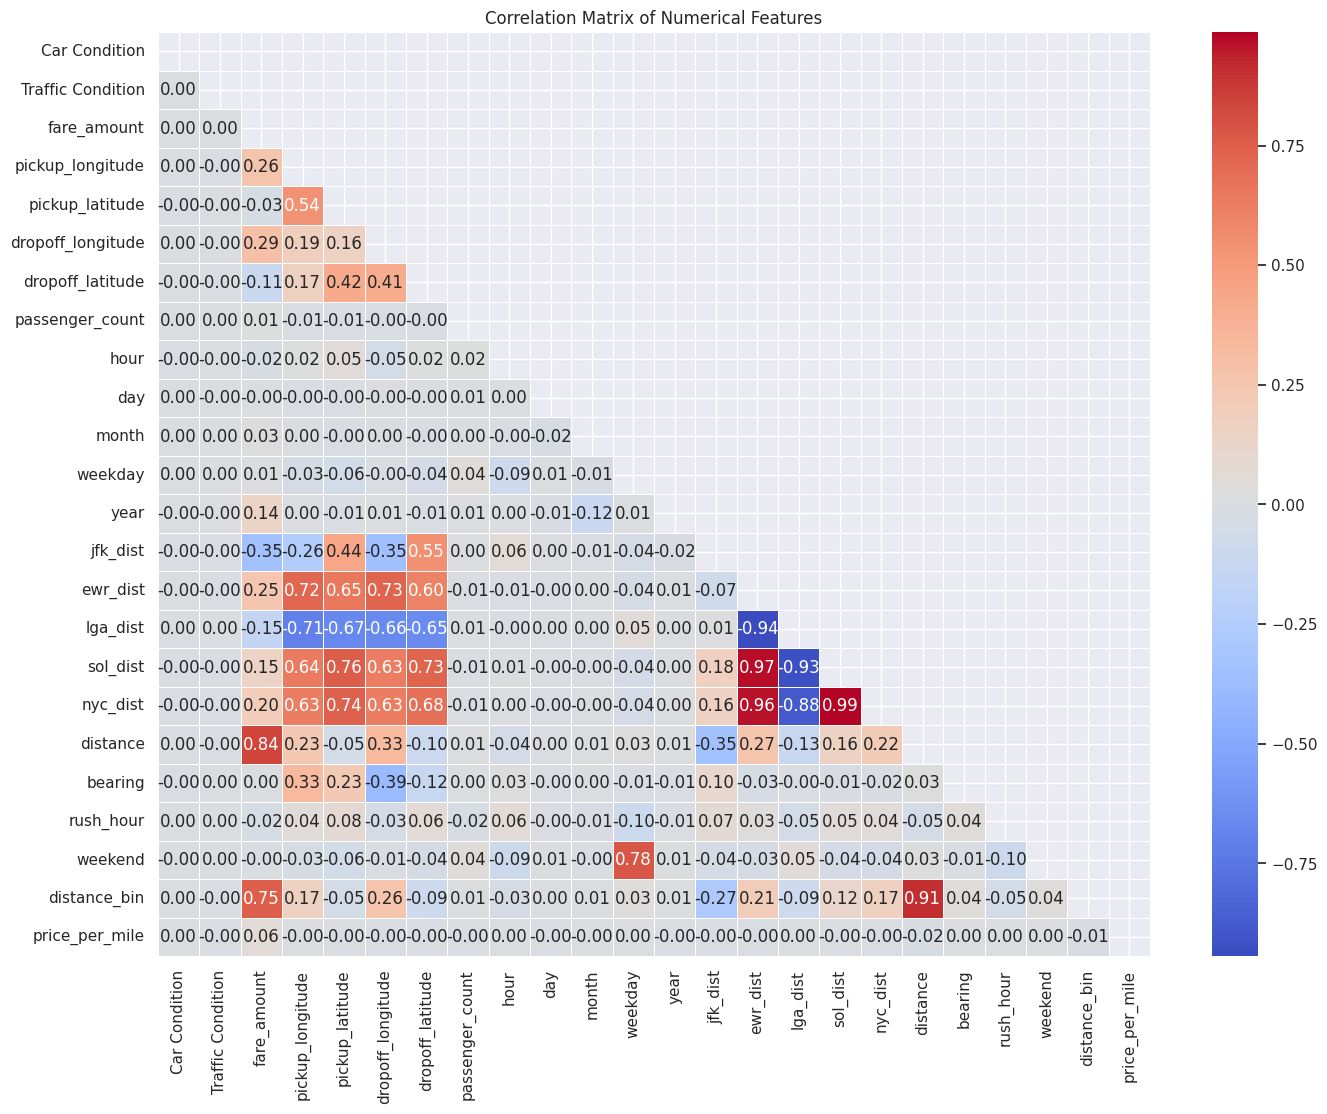

In [22]:
# ===============================
# 5. Exploratory Data Analysis (EDA)
# ===============================
# Correlation matrix for numerical features
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(correlation_matrix)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, mask=mask)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



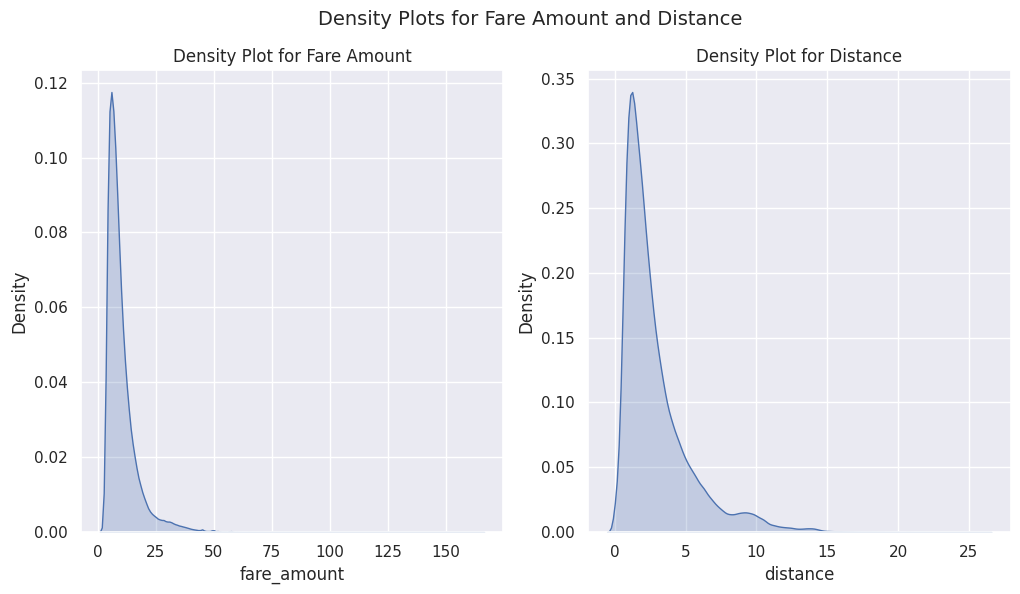

In [23]:
# Density plots for fare_amount and distance
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.kdeplot(data=df['fare_amount'], ax=axes[0], fill=True)
axes[0].set_title('Density Plot for Fare Amount')
sns.kdeplot(data=df['distance'], ax=axes[1], fill=True)
axes[1].set_title('Density Plot for Distance')
plt.suptitle('Density Plots for Fare Amount and Distance', fontsize=14)
plt.show()

In [24]:
filtered_df_copy = df.copy()

filtered_df_copy.drop(['key', 'User Name', 'Driver Name'], axis=1, inplace=True)

categorical_cols = ['Car Condition', 'Traffic Condition', 'Weather', 'time_of_day', 'distance_bin']

# Apply Label Encoding to each categorical column
label_encoder = LabelEncoder()
for col in categorical_cols:
    if col in filtered_df_copy.columns:
        filtered_df_copy[col] = label_encoder.fit_transform(filtered_df_copy[col])

correlation_matrix_copy = filtered_df_copy.corr()
fare_amount_correlation_copy = correlation_matrix_copy['fare_amount']
print(fare_amount_correlation_copy)


Car Condition        0.002919
Weather             -0.000047
Traffic Condition    0.000440
fare_amount          1.000000
pickup_longitude     0.256053
pickup_latitude     -0.030241
dropoff_longitude    0.287779
dropoff_latitude    -0.112603
passenger_count      0.014273
hour                -0.018478
day                 -0.000749
month                0.029244
weekday              0.006339
year                 0.137984
jfk_dist            -0.346789
ewr_dist             0.250378
lga_dist            -0.147364
sol_dist             0.149787
nyc_dist             0.195559
distance             0.836573
bearing              0.001226
minute              -0.008185
day_of_year          0.029063
quarter              0.026647
time_of_day          0.014695
rush_hour           -0.024458
weekend             -0.004893
distance_bin         0.752077
price_per_mile       0.055798
Name: fare_amount, dtype: float64


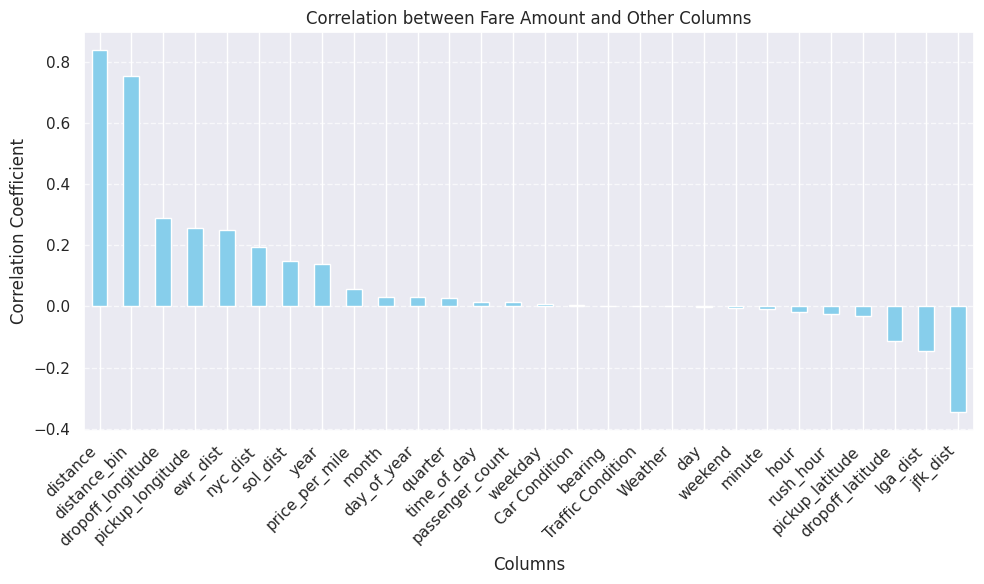

In [25]:
# Plot correlation with fare amount
sorted_correlation = fare_amount_correlation_copy.drop('fare_amount').sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sorted_correlation.plot(kind='bar', color='skyblue')
plt.title('Correlation between Fare Amount and Other Columns')
plt.xlabel('Columns')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

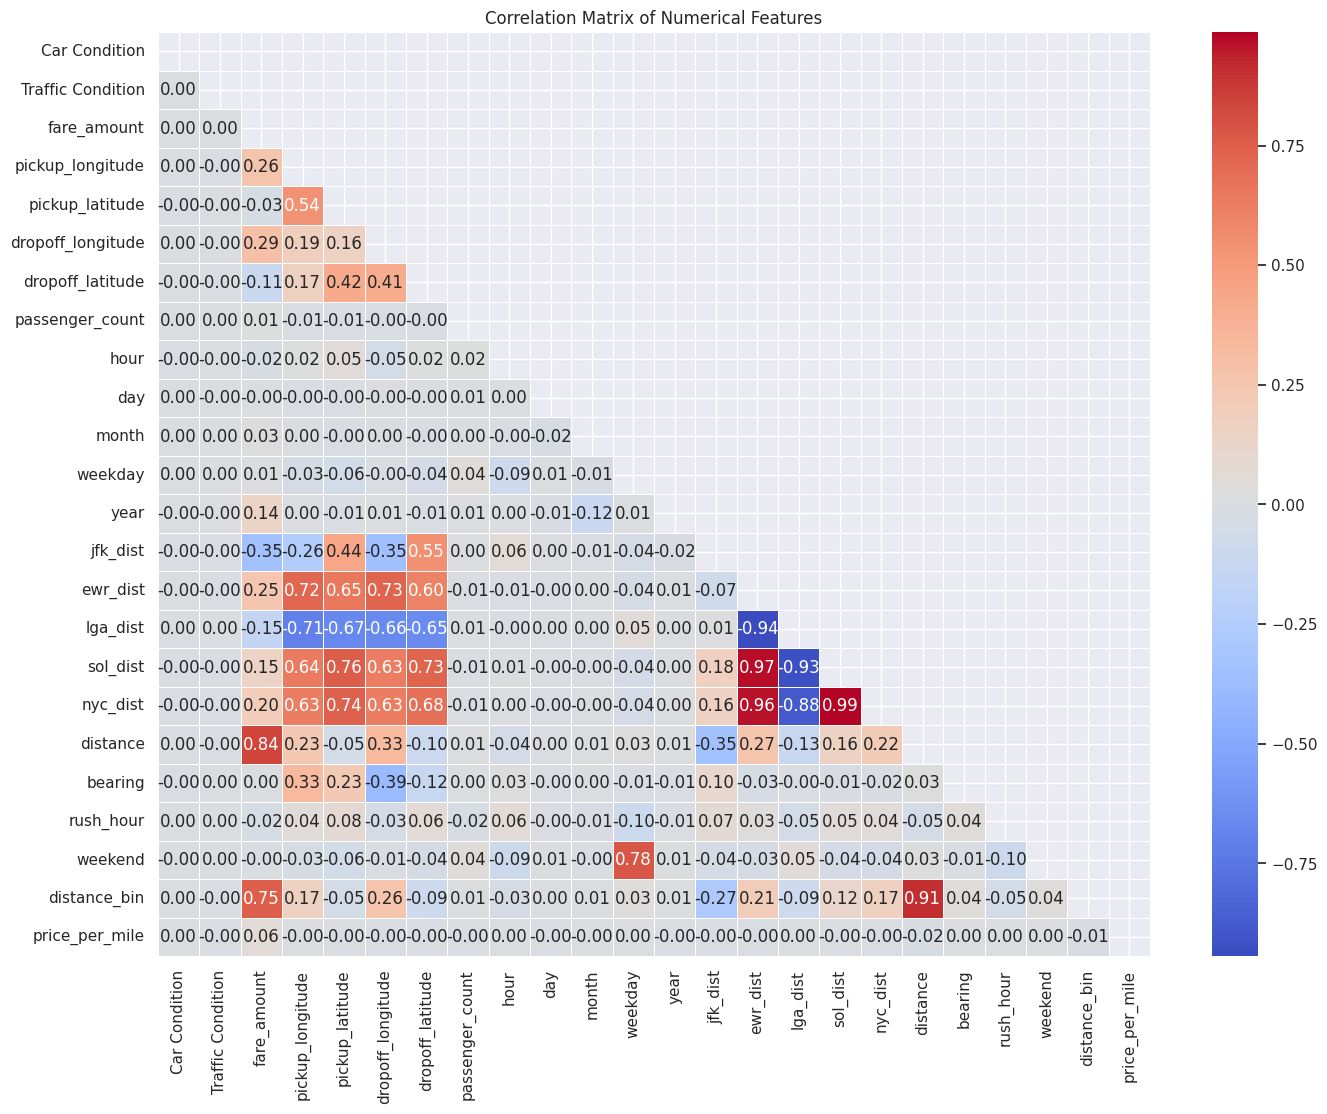

In [26]:
# Correlation matrix for numerical features
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(correlation_matrix)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, mask=mask)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

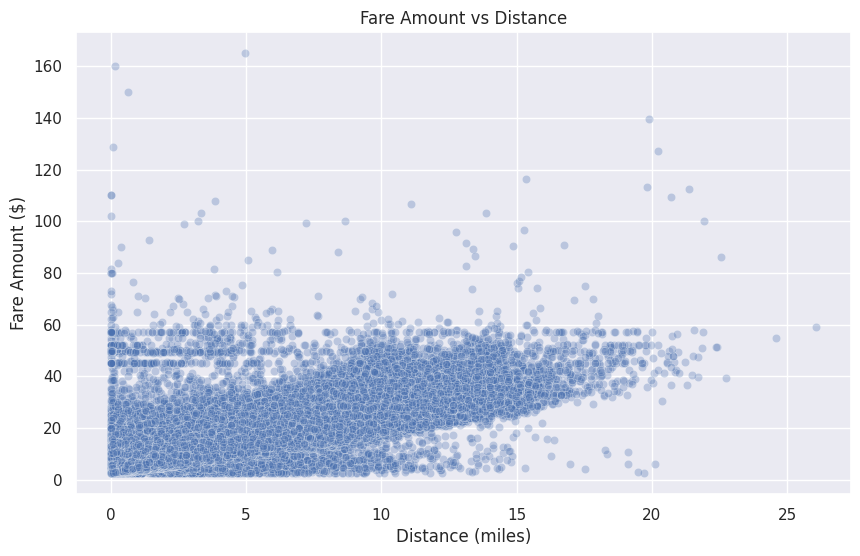

In [27]:
# ===============================
# 6. Visualizing Key Relationships
# ===============================
# Scatter plot: Distance vs Fare Amount
plt.figure(figsize=(10, 6))
sns.scatterplot(x='distance', y='fare_amount', data=df, alpha=0.3)
plt.title('Fare Amount vs Distance')
plt.xlabel('Distance (miles)')
plt.ylabel('Fare Amount ($)')
plt.show()

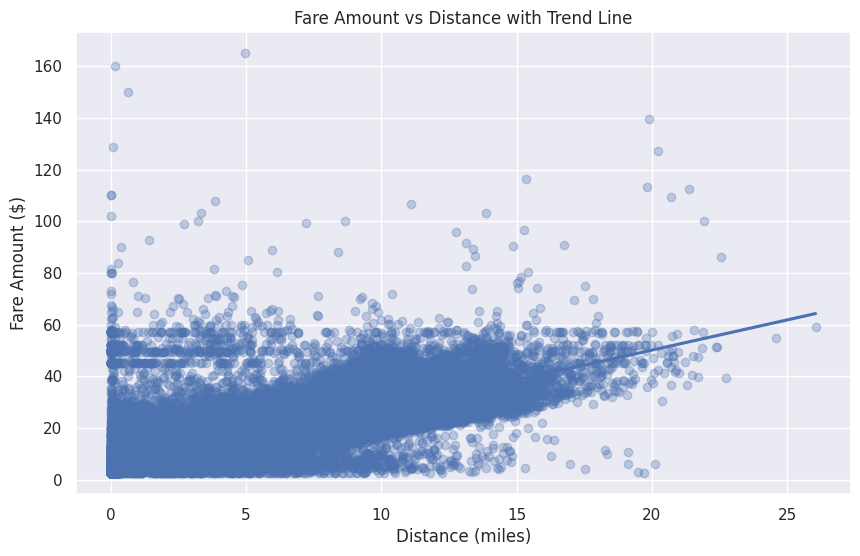

In [28]:
# Scatter plot with Regression Line
plt.figure(figsize=(10, 6))
sns.regplot(x='distance', y='fare_amount', data=df, scatter_kws={'alpha':0.3})
plt.title('Fare Amount vs Distance with Trend Line')
plt.xlabel('Distance (miles)')
plt.ylabel('Fare Amount ($)')
plt.show()


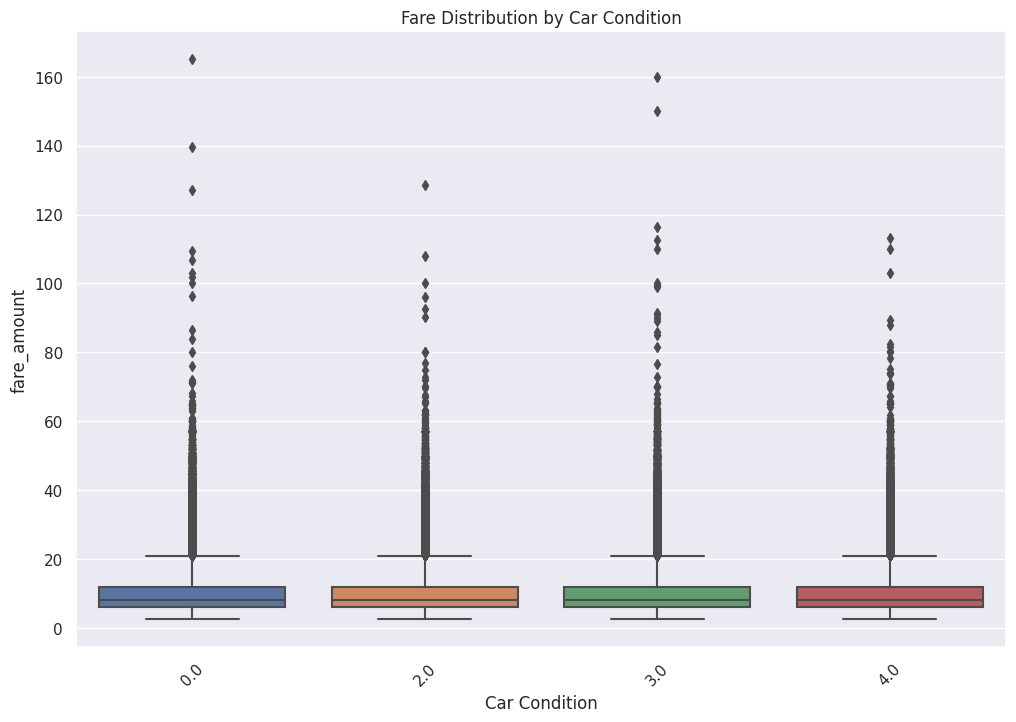


Mean fare by Car Condition:
3.0: $10.17
4.0: $10.15
2.0: $10.14
0.0: $10.10


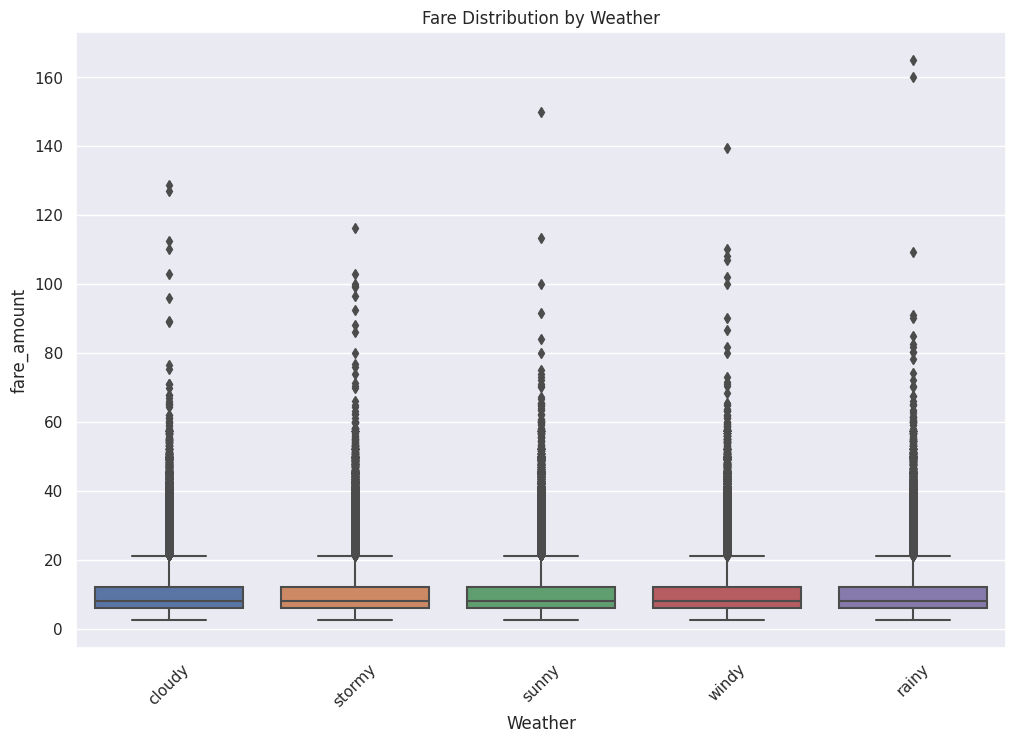


Mean fare by Weather:
cloudy: $10.15
stormy: $10.15
windy: $10.14
sunny: $10.14
rainy: $10.13


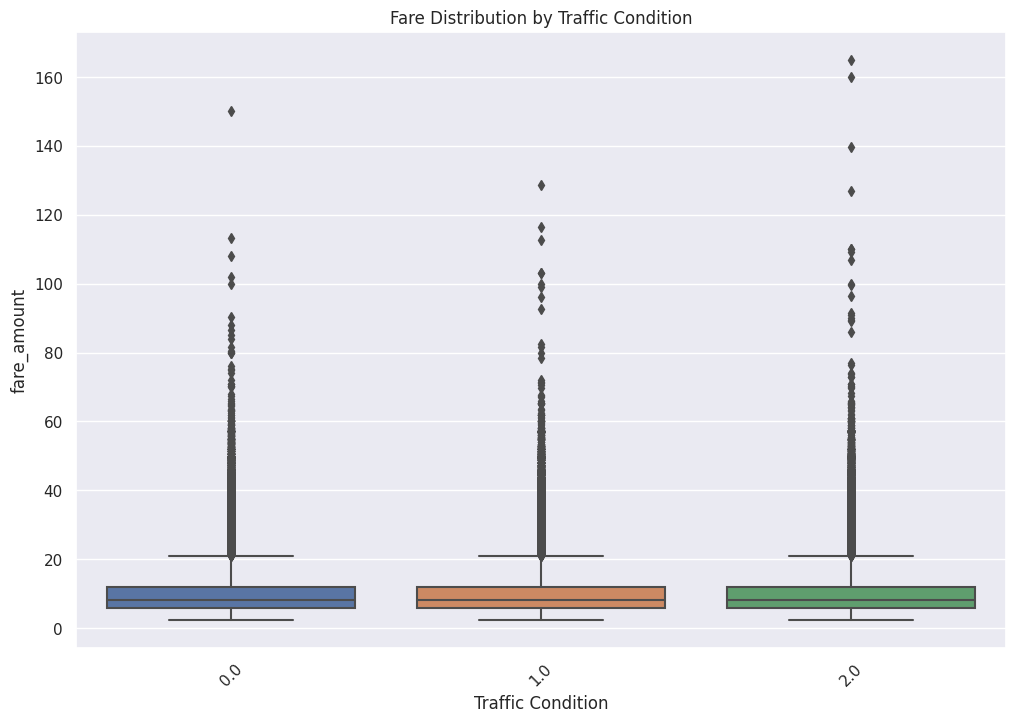


Mean fare by Traffic Condition:
1.0: $10.15
2.0: $10.14
0.0: $10.13


In [29]:
# Boxplots for Categorical Variables
for cat_var in ['Car Condition', 'Weather', 'Traffic Condition']:
    plt.figure(figsize=(12, 8))
    sns.boxplot(x=cat_var, y='fare_amount', data=df)
    plt.title(f'Fare Distribution by {cat_var}')
    plt.xticks(rotation=45)
    plt.show()
    
    # Mean fare by category
    category_means = df.groupby(cat_var)['fare_amount'].mean().sort_values(ascending=False)
    print(f"\nMean fare by {cat_var}:")
    for category, mean_fare in category_means.items():
        print(f"{category}: ${mean_fare:.2f}")


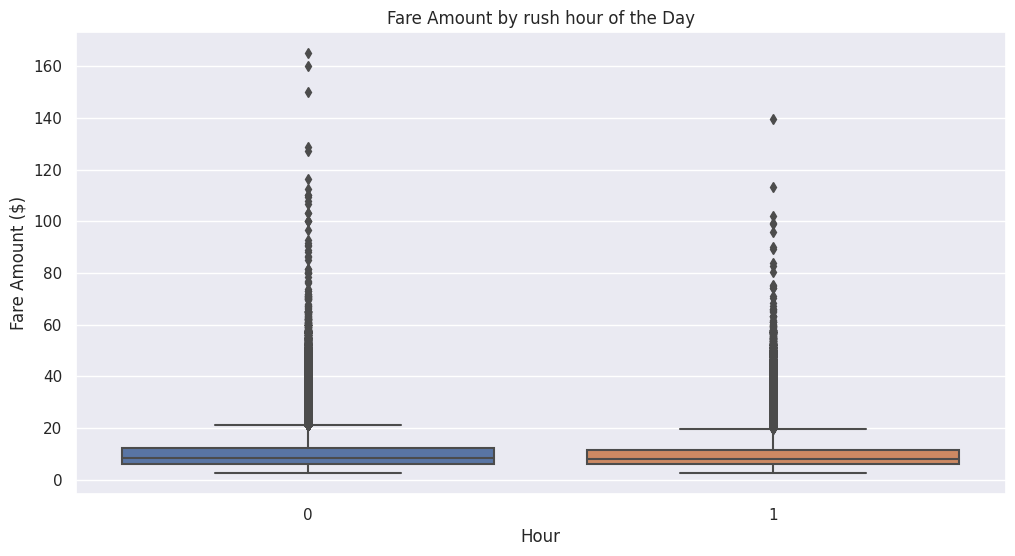

In [30]:
# ===============================
# 7. Temporal Analysis
# ===============================
# Boxplot: Fare Amount by Hour of the Day
plt.figure(figsize=(12, 6))
sns.boxplot(x='rush_hour', y='fare_amount', data=df)
plt.title('Fare Amount by rush hour of the Day')
plt.xlabel('Hour')
plt.ylabel('Fare Amount ($)')
plt.show()

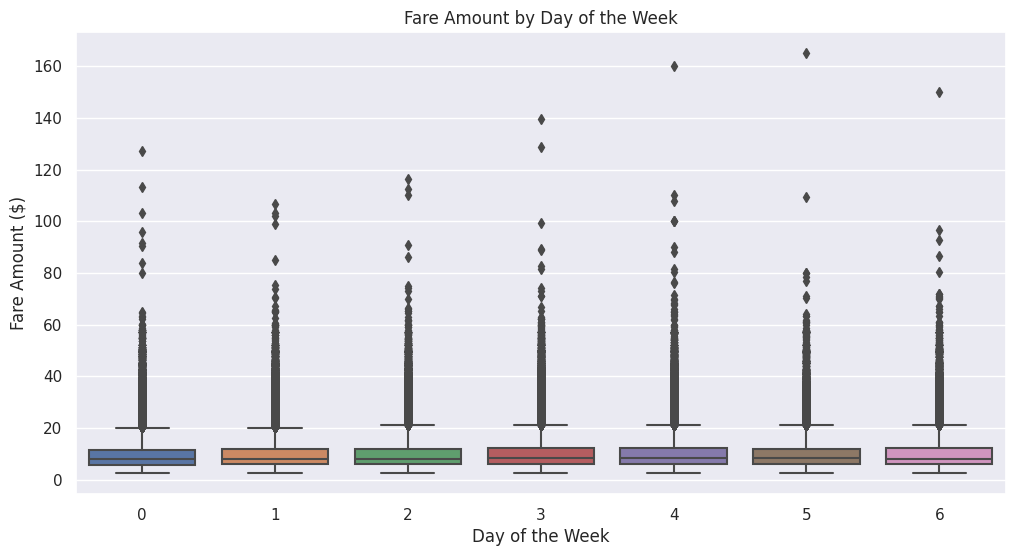

In [31]:
# Boxplot: Fare Amount by Day of the Week
plt.figure(figsize=(12, 6))
sns.boxplot(x='weekday', y='fare_amount', data=df)
plt.title('Fare Amount by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Fare Amount ($)')
plt.show()

In [32]:
# ===============================
# 8. Geospatial Analysis
# ===============================
# Interactive Scatter Map for Pick-up Locations
sample_data = df.sample(n=500, random_state=42)
df_map = [
    go.Scattermapbox(
        lat=sample_data['pickup_latitude'],
        lon=sample_data['pickup_longitude'],
        mode='markers',
        marker=dict(size=5, color='yellow', opacity=1),
    )
]
layout = go.Layout(
    autosize=False,
    mapbox=dict(
        bearing=10,
        pitch=60,
        zoom=13,
        center=dict(lat=40.721319, lon=-73.987130),
        style="carto-positron"
    ),
    width=900,
    height=600,
    title="Pick-up Locations in New York"
)
fig = dict(data=df_map, layout=layout)
offline.iplot(fig)


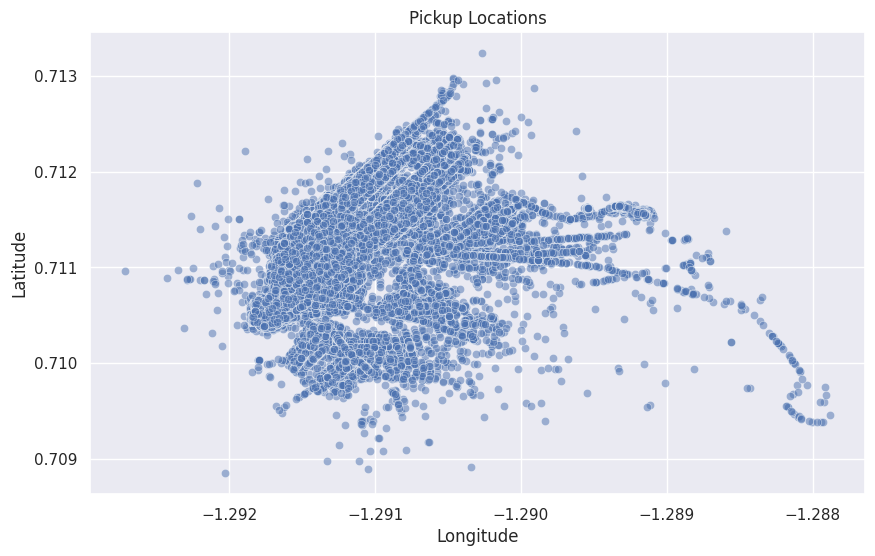

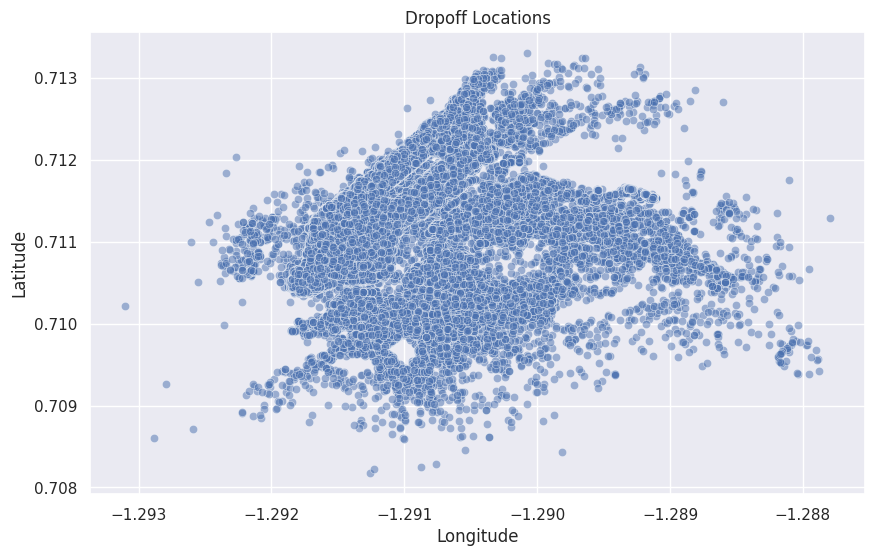

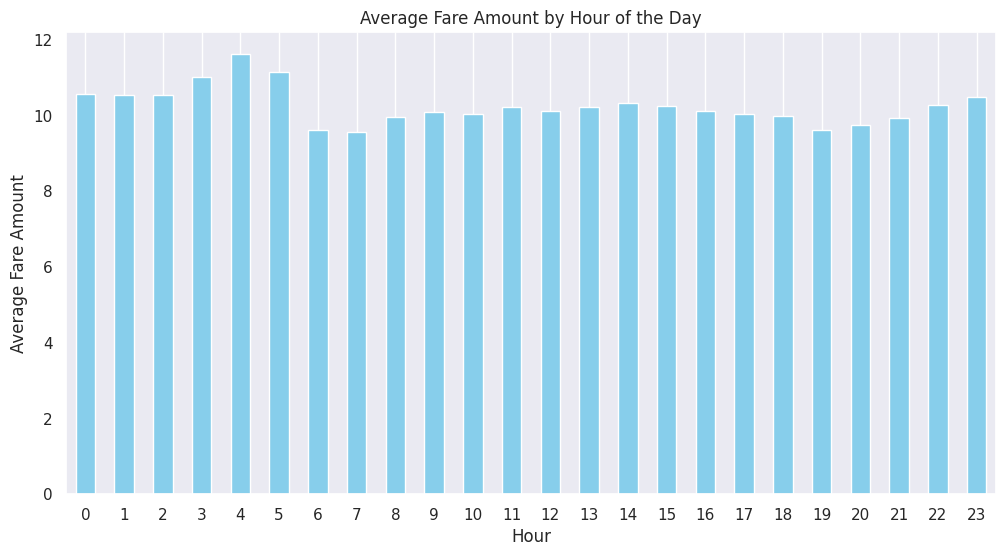

<ipython-input-33-47bf85d2c0fa>:28: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



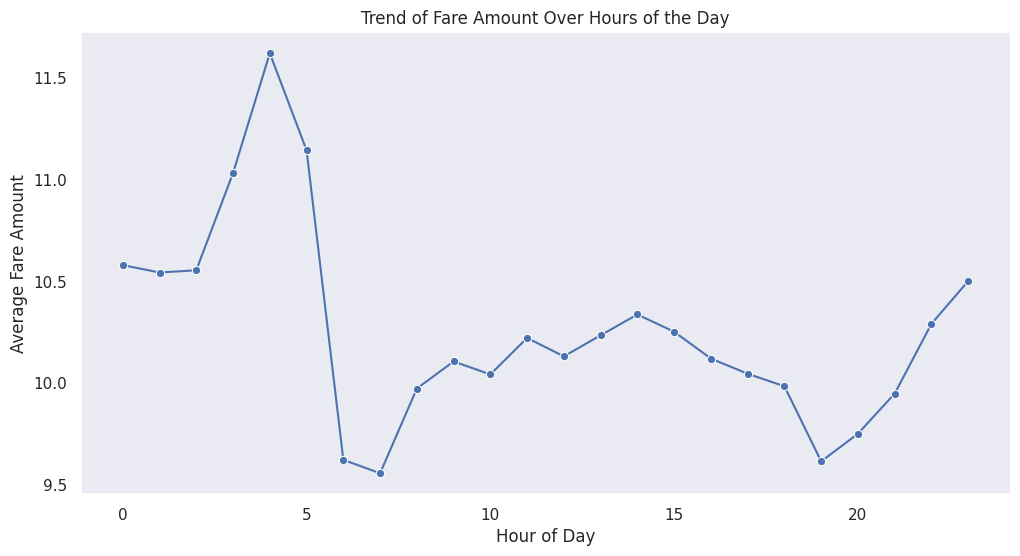

In [33]:
# Geospatial Analysis
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['pickup_longitude'], y=df['pickup_latitude'], alpha=0.5)
plt.title('Pickup Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['dropoff_longitude'], y=df['dropoff_latitude'], alpha=0.5)
plt.title('Dropoff Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Bar chart for average fare by hour
plt.figure(figsize=(12, 6))
df.groupby('hour')['fare_amount'].mean().plot(kind='bar', color='skyblue')
plt.title('Average Fare Amount by Hour of the Day')
plt.xlabel('Hour')
plt.ylabel('Average Fare Amount')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

# Lineplot for fare trends over time
plt.figure(figsize=(12, 6))
sns.lineplot(x='hour', y='fare_amount', data=df, estimator='mean', ci=None, marker='o')
plt.title('Trend of Fare Amount Over Hours of the Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Fare Amount')
plt.grid()
plt.show()

In [34]:
# Drop invalid location columns
df.drop(['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude'], axis=1, inplace=True)

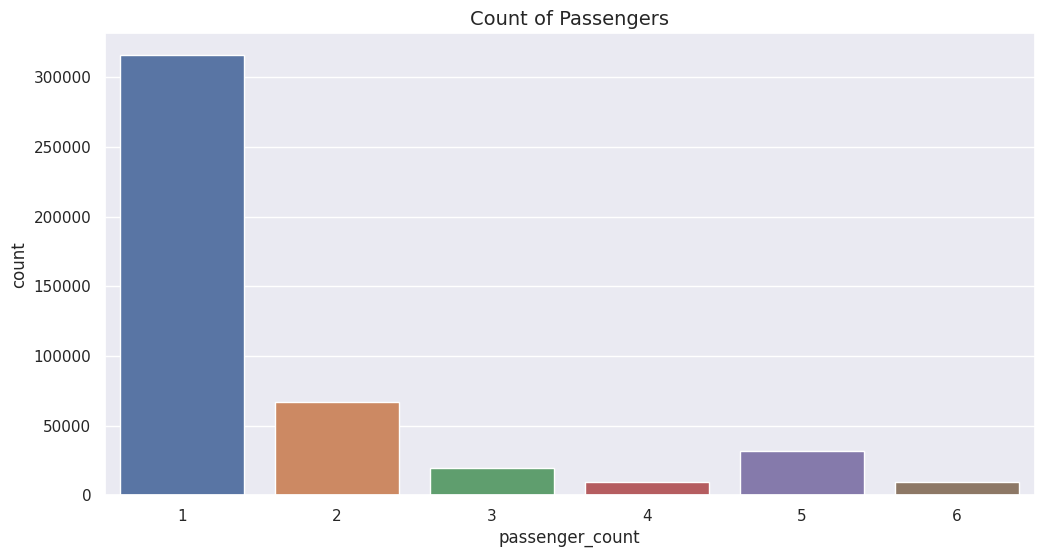

In [35]:
# Count plot for passenger count
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='passenger_count')
plt.title('Count of Passengers', fontsize=14)
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



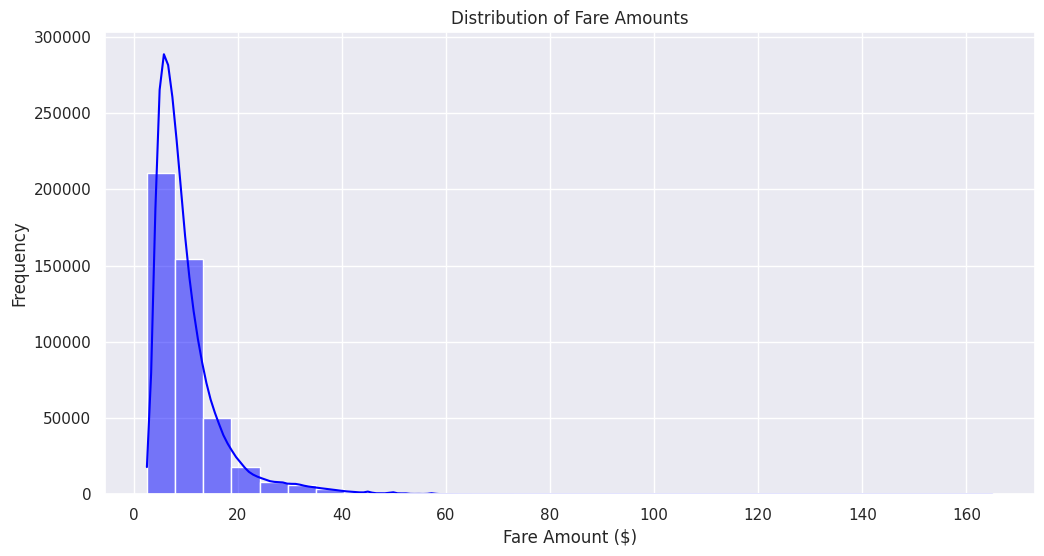

In [36]:
plt.figure(figsize=(12, 6))
sns.histplot(df['fare_amount'], bins=30, kde=True, color='blue')
plt.title('Distribution of Fare Amounts')
plt.xlabel('Fare Amount ($)')
plt.ylabel('Frequency')
plt.show()

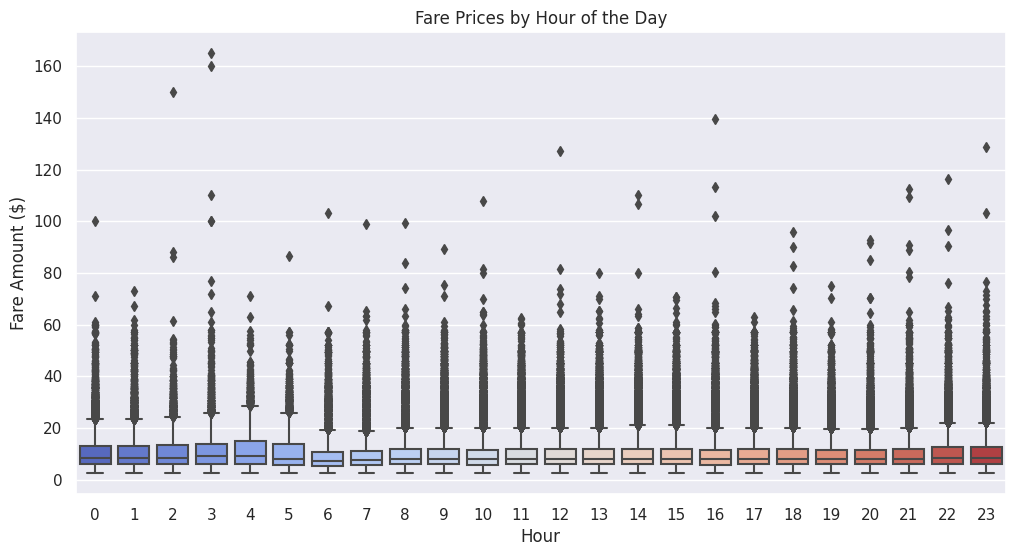

In [37]:
# Hourly trend of fare prices
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['hour'], y=df['fare_amount'], palette='coolwarm')
plt.title('Fare Prices by Hour of the Day')
plt.xlabel('Hour')
plt.ylabel('Fare Amount ($)')
plt.show()


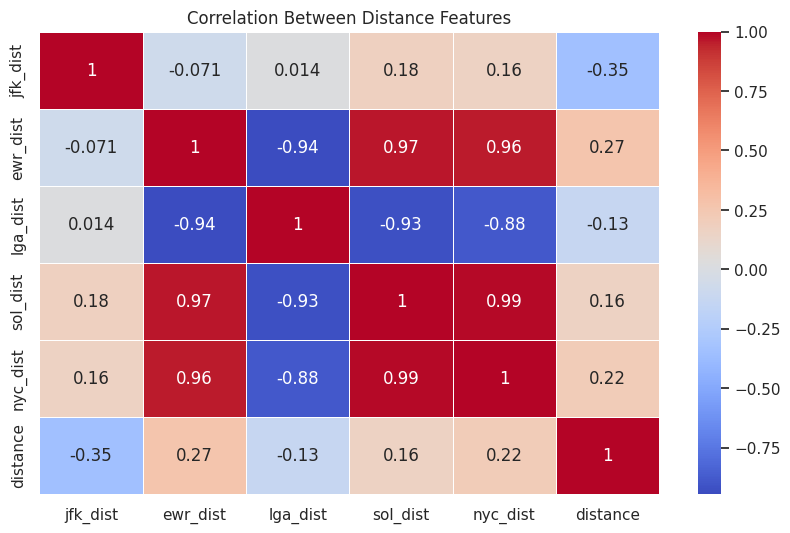

In [38]:
# Heatmap of distance relationships
distance_cols = ['jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist', 'distance']
plt.figure(figsize=(10, 6))
sns.heatmap(df[distance_cols].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Between Distance Features')
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning:

unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



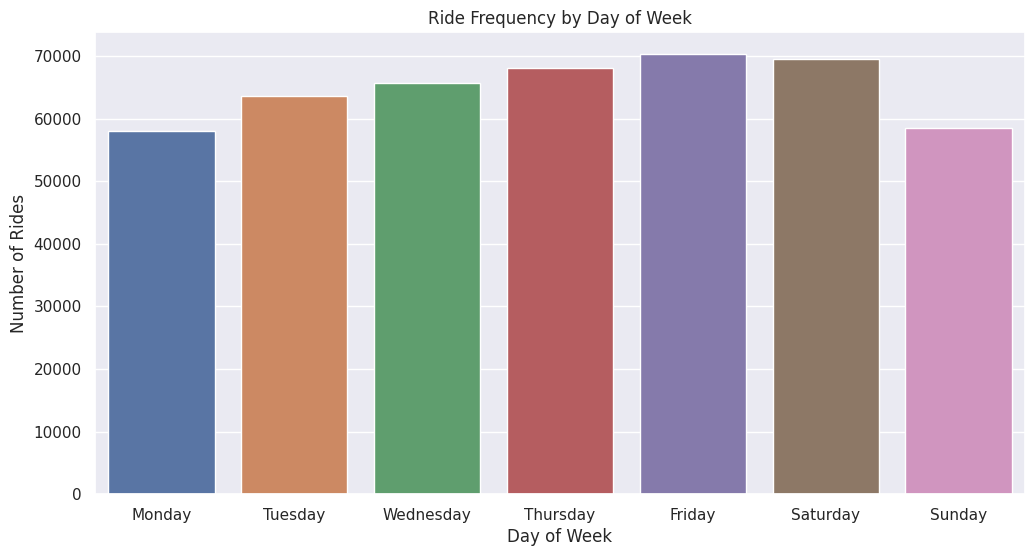

In [39]:
# Day of week patterns
weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_counts = df.groupby('weekday').size()
plt.figure(figsize=(12, 6))
sns.barplot(x=[weekday_names[i] for i in range(7)], y=[weekday_counts.get(i, 0) for i in range(7)])
plt.title('Ride Frequency by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Rides')
plt.show()


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning:

unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



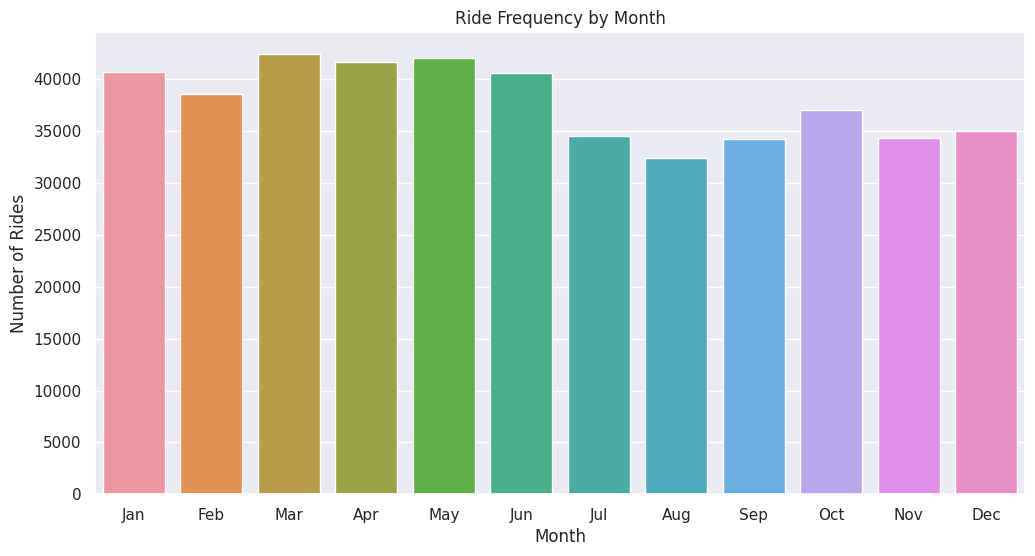

In [42]:
# Monthly patterns
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_counts = df.groupby('month').size()
plt.figure(figsize=(12, 6))
sns.barplot(x=[month_names[i-1] for i in range(1, 13)], y=[monthly_counts.get(i, 0) for i in range(1, 13)])
plt.title('Ride Frequency by Month')
plt.xlabel('Month')
plt.ylabel('Number of Rides')
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



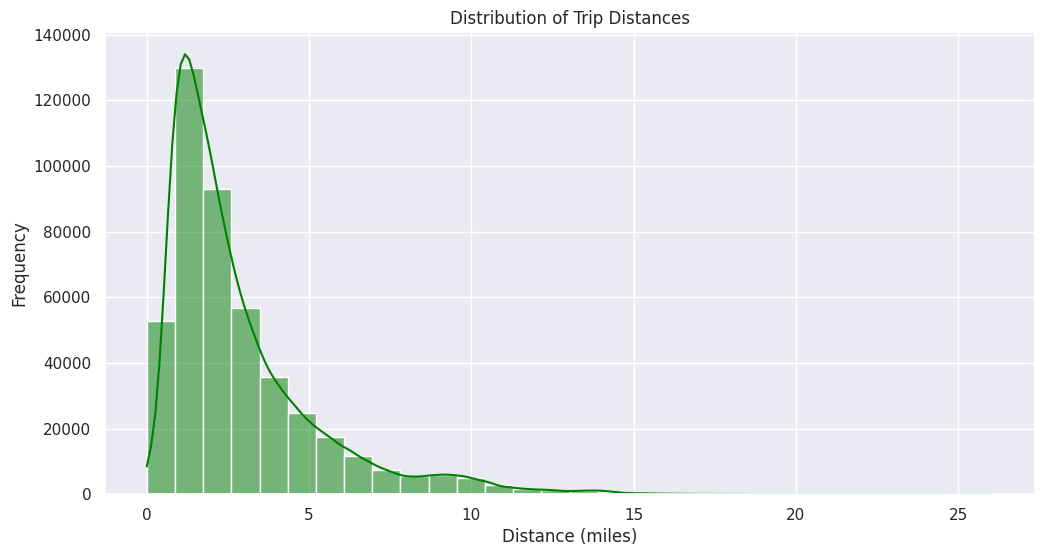

In [43]:
# New Visualization: Distribution of trip distances
plt.figure(figsize=(12, 6))
sns.histplot(df['distance'], bins=30, kde=True, color='green')
plt.title('Distribution of Trip Distances')
plt.xlabel('Distance (miles)')
plt.ylabel('Frequency')
plt.show()


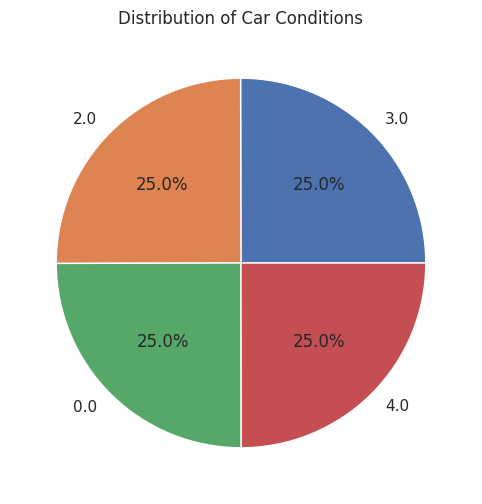

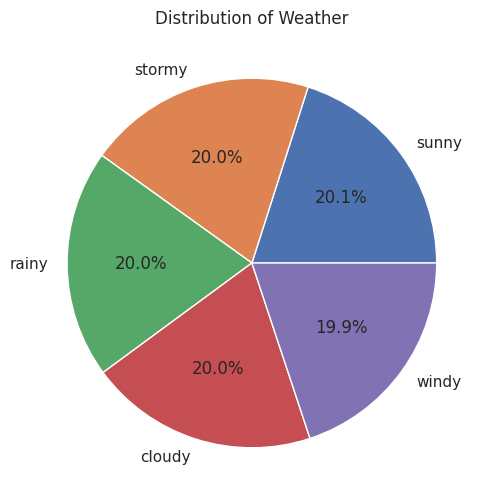

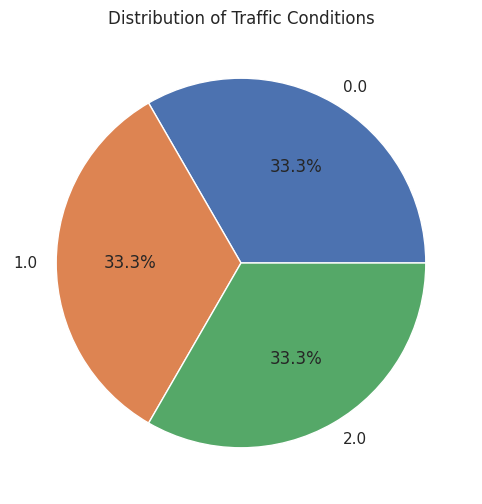

In [44]:
# ===============================
# 9. Categorical Distributions
# ===============================
# Pie chart: Distribution of Car Conditions
plt.figure(figsize=(8, 6))
df['Car Condition'].value_counts().plot.pie(autopct='%1.1f%%', startangle=0)
plt.title('Distribution of Car Conditions')
plt.ylabel('')
plt.show()

# Pie chart: Distribution of Weather Conditions
plt.figure(figsize=(8, 6))
df['Weather'].value_counts().plot.pie(autopct='%1.1f%%', startangle=0)
plt.title('Distribution of Weather')
plt.ylabel('')
plt.show()

# Pie chart: Distribution of Traffic Conditions
plt.figure(figsize=(8, 6))
df['Traffic Condition'].value_counts().plot.pie(autopct='%1.1f%%', startangle=0)
plt.title('Distribution of Traffic Conditions')
plt.ylabel('')
plt.show()

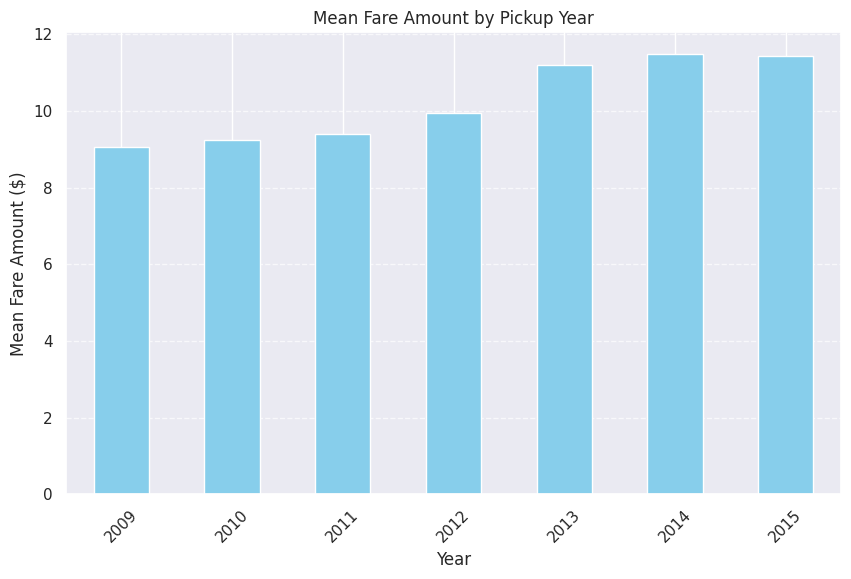

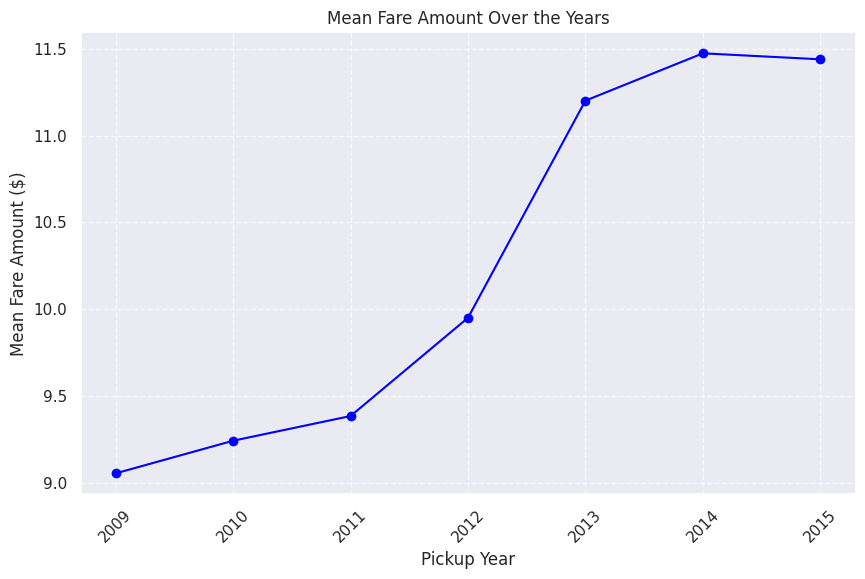

In [45]:
# ===============================
# 10. Temporal Trends
# ===============================
# Line plot: Fare Trends Over Years
fare_by_year = df.groupby('year')['fare_amount'].mean()
fare_by_year.plot(kind='bar', figsize=(10, 6), color='skyblue')
plt.title('Mean Fare Amount by Pickup Year')
plt.xlabel('Year')
plt.ylabel('Mean Fare Amount ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Line plot: Fare Trends Over Time
plt.figure(figsize=(10, 6))
plt.plot(fare_by_year.index, fare_by_year, marker='o', linestyle='-', color='blue')
plt.title('Mean Fare Amount Over the Years')
plt.xlabel('Pickup Year')
plt.ylabel('Mean Fare Amount ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fare_by_year.index, rotation=45)
plt.show()

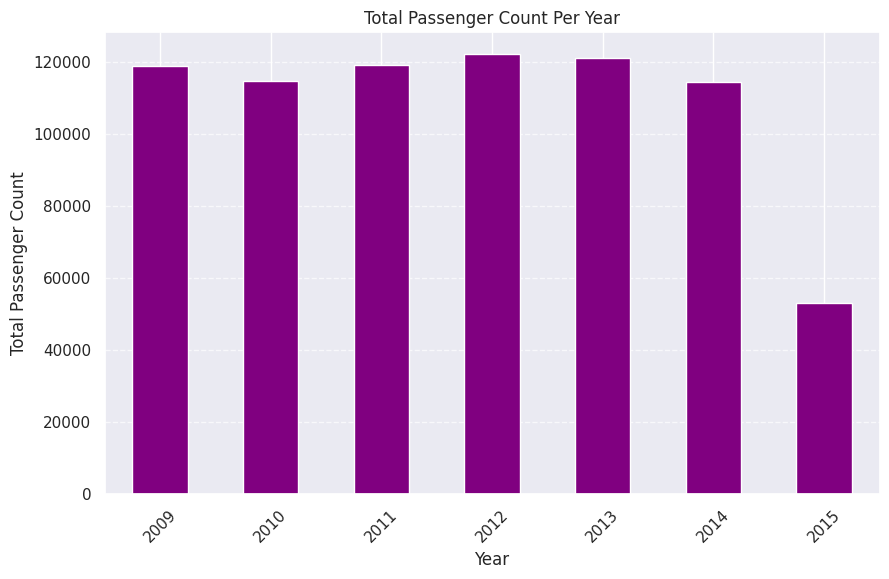

In [46]:
# ===============================
# 11. Passenger Count Analysis
# ===============================
# Passenger Count Over Years
passenger_count_by_year = df.groupby('year')['passenger_count'].sum()
plt.figure(figsize=(10, 6))
passenger_count_by_year.plot(kind='bar', color='purple')
plt.title('Total Passenger Count Per Year')
plt.xlabel('Year')
plt.ylabel('Total Passenger Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


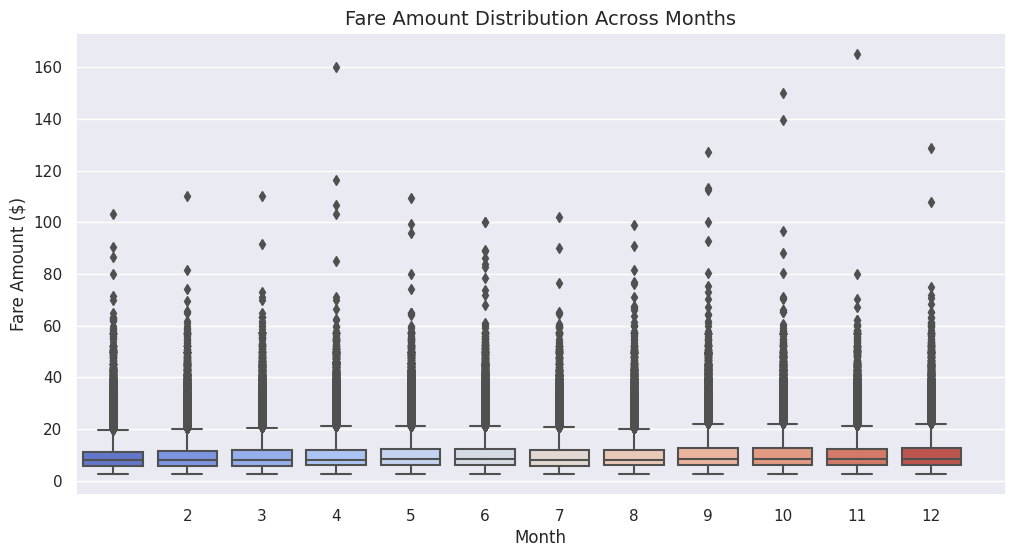

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



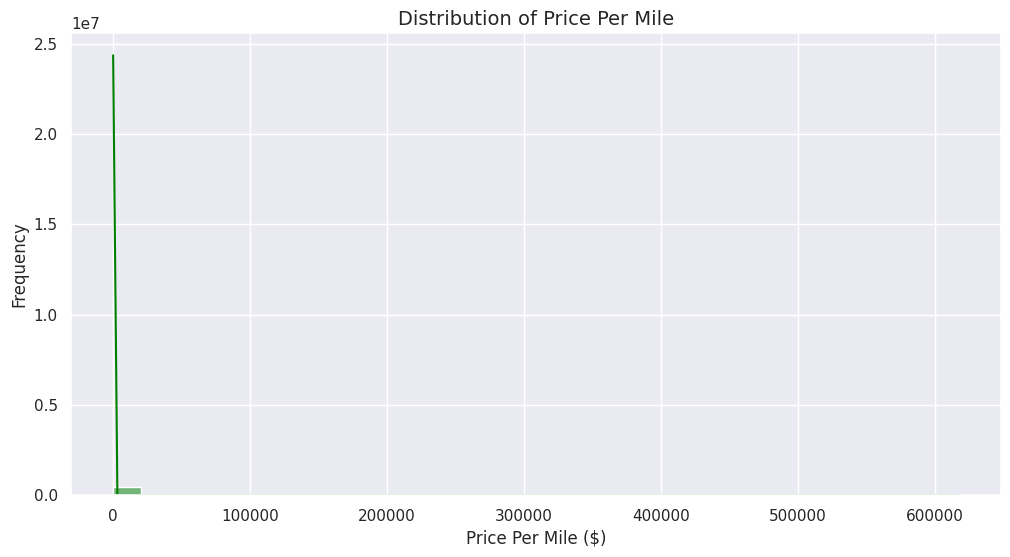

<ipython-input-47-9534fa41e5f0>:24: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



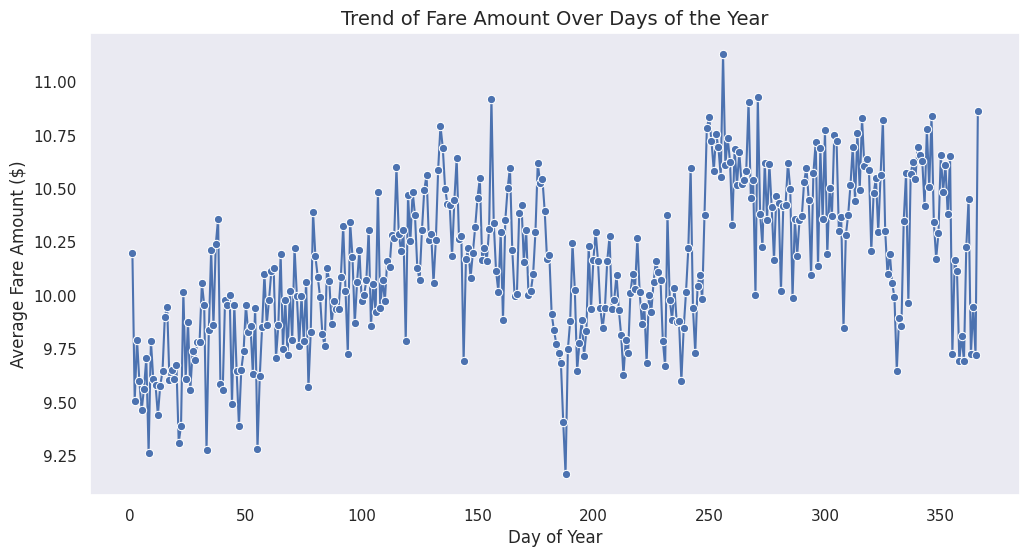

<ipython-input-47-9534fa41e5f0>:33: FutureWarning:

Passing `palette` without assigning `hue` is deprecated.

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



In [ ]:
correlation_matrix = df.select_dtypes(include=['number']).corr()
fare_amount_correlation = correlation_matrix['fare_amount']


#  Fare Distribution Across Months
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['month'], y=df['fare_amount'], palette='coolwarm')
plt.title('Fare Amount Distribution Across Months', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Fare Amount ($)')
plt.xticks(range(1, 13))
plt.show()

#  Price Per Mile Distribution
plt.figure(figsize=(12, 6))
sns.histplot(df['price_per_mile'], bins=30, kde=True, color='green')
plt.title('Distribution of Price Per Mile', fontsize=14)
plt.xlabel('Price Per Mile ($)')
plt.ylabel('Frequency')
plt.show()

#  Fare Variations by Day of the Year
plt.figure(figsize=(12, 6))
sns.lineplot(x=df['day_of_year'], y=df['fare_amount'], estimator='mean', ci=None, marker='o')
plt.title('Trend of Fare Amount Over Days of the Year', fontsize=14)
plt.xlabel('Day of Year')
plt.ylabel('Average Fare Amount ($)')
plt.grid()
plt.show()

#  Fare Amount Across Different Traffic Conditions (Swarm Plot)
plt.figure(figsize=(12, 6))
sns.swarmplot(x=df['Traffic Condition'], y=df['fare_amount'], palette='coolwarm', size=2)
plt.title('Impact of Traffic Condition on Fare Amounts', fontsize=14)
plt.xlabel('Traffic Condition')
plt.ylabel('Fare Amount ($)')
plt.xticks(rotation=30)
plt.show()
